### Notebook comparing IEDBcluster and epicore
This notebook employs immunopeptidome data from a benign [reference dataset](https://doi.org/10.1186/s13059-025-03763-8).

In [1]:
# imports
import pandas as pd
import subprocess
import ast
import matplotlib.pyplot as plt
from matplotlib_venn import venn2

#### Prepare IEDBcluster and epicore input
Identify the protein to which the most peptides of contained in the dataset map and take the first 1000 peptides as input. 

In [2]:
# identify protein showing the most peptides
df = pd.read_csv('../epicore_analysis/complexity_reduction/class2/epicore_result.csv', index_col=[0])
df['sequence'].apply(lambda cell: set(ast.literal_eval(cell))).str.len().max()

np.int64(3377)

In [3]:
df[df['sequence'].apply(lambda cell: set(ast.literal_eval(cell))).str.len()==3377].iloc[0]

accession                                                  sp|P60709|ACTB_HUMAN
sequence                      ['MDDDIAALVVDNGSGMCKAGFAGDDAPRA', 'MDDDIAALVVD...
start                         ['0', '0', '0', '1', '1', '1', '1', '1', '1', ...
end                           ['28', '27', '27', '12', '9', '9', '9', '9', '...
peptide_index                 ['614574', '957628', '781477', '962283', '8952...
sample                        ['BD-ZH12_ESOPHAGUS', 'BD-ZH17_GALLBLADDER', '...
condition                     ['benign', 'benign', 'benign', 'benign', 'beni...
grouped_peptides_start        [[0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,...
grouped_peptides_end          [[28, 27, 27, 12, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9...
grouped_peptides_sequence     [['MDDDIAALVVDNGSGMCKAGFAGDDAPRA', 'MDDDIAALVV...
grouped_peptides_sample       [['BD-ZH12_ESOPHAGUS', 'BD-ZH17_GALLBLADDER', ...
grouped_peptides_condition    [['benign', 'benign', 'benign', 'benign', 'ben...
sequence_group_mapping        [0, 0, 0, 

In [4]:
# take 1000 peptides from sp|P60709|ACTB_HUMAN
for seq in list(set(ast.literal_eval(df[df['sequence'].apply(lambda cell: set(ast.literal_eval(cell))).str.len()==3377].iloc[0]['sequence'])))[0:1000]:
    print(seq)

APLNPKANREKMTQIM
SGRTTGIVMDSGDGVTH
RMQKEITALAPSTMKIKII
PEEHPVLLTEAPLNPKANREKMTQIMFE
IVTNWDDMEKIWHHTFYNELRVAPEEHPVL
IAPPERKYS
QQMWISKQEYD
DLAGRDLTDYLMKILTER
THTVPIYE
FQPSFLGMESCGIHET
RKYSVWIGGSILA
PSIVGRPRH
AGDDAPRAVFPSIVGRPRHQGVMVGMGQ
KYPIEHGIVTNWDDMEKIWHHTFY
NPKANREK
SGGTTMYP
IKIIAPPERKYS
GRDLTDYLMKI
GQVITIGNERF
ALPHAILRLDLAGRDLTDY
KEITALAPSTMKIKIIAPPERKY
ISKQEYDESGP
PKANREKMTQIM
YPGIADRMQKEITALAPSTM
PLNPKANREKM
GIADRMQKEITALAPSTMK
FQQMWISKQEYDESGPSIV
TMKIKIIAPPER
MEKIWHHTFY
LYASGRTTGIVMDS
MQKEITALAPS
FAGDDAPRAVFPSIVGRPRHQGVM
QEYDESGP
SLYASGRTTGIVMDSGDGVTHTVPIYEGY
LPDGQVITIGNERFR
PSTMKIKIIAPPE
AIQAVLSLYASGRTT
ESGPSIVHRK
HTVPIYEGYALPHAIL
GILTLKYPI
FAGDDAPRA
LMKILTERGYSFTTTAEREIV
GFAGDDAPRAVFPSIVGRPRHQG
LTDYLMKILTERGYSFT
AMYVAIQAVLSL
LYASGRTTGIVMDSGDGVT
APLNPKANREKMTQI
NREKMTQIMFETFNTPAMY
TAASSSSLEKSYELPDG
EYDESGPS
GQKDSYVG
DIRKDLYANTVLSGGTTMYPGIA
KIKIIAPPERKYSVWIGGSILASLSTF
YVAIQAVLSLYASGRTTGIVMDSGD
YASGRTTGIVM
EKMTQIMFETFNTPAMYV
SKRGILTLKYPIE
LAGRDLTDYLM
TDYLMKILTERGYSFT
IVTNWDDMEKIWH

In [12]:
benign_df = pd.read_csv('../epicore_analysis/reference_class2.csv', index_col=[0])
subset_df = benign_df[benign_df['sequence'].isin(list(set(ast.literal_eval(df[df['sequence'].apply(lambda cell: set(ast.literal_eval(cell))).str.len()==3377].iloc[0]['sequence'])))[0:1000])]
subset_df.to_csv('epicore_input.csv')

#### Run epicore
IEDBcluster was run inside the webtool. 

In [14]:
subprocess.run(['epicore', '--reference_proteome','/mnt/volume/jana/thesis/gith/masterthesis/uniprotkb_reviewed_true_AND_proteome_UP000005640_9606_release_2024_01_2024_02_23.fasta' , '--out_dir', f'epicore_out', 'generate-epicore-csv', '--min_epi_length', '9', '--min_overlap', '9', '--seq_column', 'sequence', '--protacc_column', 'accessions', '--delimiter', ';', '--evidence_file', 'epicore_input.csv', '--sample_column', 'sample', '--condition_column', 'condition', '--start_column', 'start', '--end_column', 'end', '--included'])

CompletedProcess(args=['epicore', '--reference_proteome', '/mnt/volume/jana/thesis/gith/masterthesis/uniprotkb_reviewed_true_AND_proteome_UP000005640_9606_release_2024_01_2024_02_23.fasta', '--out_dir', 'epicore_out', 'generate-epicore-csv', '--min_epi_length', '9', '--min_overlap', '9', '--seq_column', 'sequence', '--protacc_column', 'accessions', '--delimiter', ';', '--evidence_file', 'epicore_input.csv', '--sample_column', 'sample', '--condition_column', 'condition', '--start_column', 'start', '--end_column', 'end', '--included'], returncode=0)

#### Compare epicore and IEDB cluster results

In [126]:
# evaluate number of clusters
epicore_df = pd.read_csv('epicore_out/epitopes.csv', index_col=[0])
print(f"Epicore identified {len(epicore_df.drop_duplicates(['whole_epitopes', 'consensus_epitopes']))}.")

iedb_df = pd.read_csv('peptide_table_c9413bbd.csv')
print(f"IEDBcluster identified {len(iedb_df['cluster consensus'].unique())-1}.")

Epicore identified 155.
IEDBcluster identified 42.


In [87]:
print(f"{len(iedb_df[iedb_df['cluster consensus'].str.contains('X')].drop_duplicates('cluster consensus'))} IEDBcluster cluster contain X.")

2 IEDBcluster cluster contain X.


In [88]:
# identify number of peptides per group
print(f"On average, {(iedb_df['cluster.sub-cluster number'].value_counts()-1).mean()} peptides are summarized in one cluster by IEDBcluster ({(iedb_df['cluster.sub-cluster number'].value_counts()-1).min()}-{(iedb_df['cluster.sub-cluster number'].value_counts()-1).max()}).")
print(f"{(epicore_df['grouped_peptides_sequence'].apply(lambda cell: len(set(ast.literal_eval(cell))))).mean()} peptides are , on average, in one epicore group ({(epicore_df['grouped_peptides_sequence'].apply(lambda cell: len(set(ast.literal_eval(cell))))).min()}-{(epicore_df['grouped_peptides_sequence'].apply(lambda cell: len(set(ast.literal_eval(cell))))).max()}).")

On average, 24.925 peptides are summarized in one cluster by IEDBcluster (0-124).
27.558139534883722 peptides are , on average, in one epicore group (1-88).


In [128]:
print(f"IEDBcluster peptide groups are, on average, {iedb_df.drop_duplicates('cluster consensus')['cluster consensus'].str.len().mean()} aa positions long ({iedb_df.drop_duplicates('cluster consensus')['cluster consensus'].str.len().min()}-{iedb_df.drop_duplicates('cluster consensus')['cluster consensus'].str.len().max()}).")
print(f"Epicore peptide groups are, on average, {epicore_df['whole_epitopes'].str.len().mean()} aa positions long ({epicore_df['whole_epitopes'].str.len().min()}-{epicore_df['whole_epitopes'].str.len().max()}).")

IEDBcluster peptide groups are, on average, 28.697674418604652 aa positions long (8-59).
Epicore peptide groups are, on average, 20.22093023255814 aa positions long (8-37).


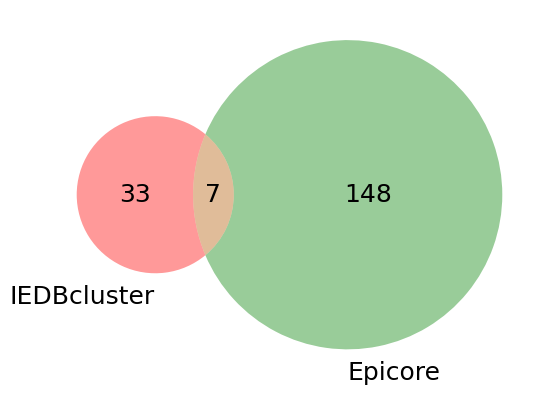

In [110]:
# identify cluster overlap 
epicore_df['seqs'] = epicore_df['grouped_peptides_sequence'].apply(lambda cell: ','.join(set(ast.literal_eval(cell))))
iedb_groups = iedb_df.groupby('cluster.sub-cluster number').agg({'peptide':list})
iedb_groups['seqs'] = iedb_groups['peptide'].apply(lambda cell: ','.join(set(cell)-{'-'}))


plot = venn2([set(iedb_groups['seqs']), set(epicore_df['seqs'])], ('IEDBcluster', 'Epicore'))
for label in plot.set_labels:
    label.set_fontsize(18)
for label in plot.subset_labels:
    label.set_fontsize(18)
plt.savefig('figures/overlap_IEDBepi.svg')



In [139]:
protein_epicore = pd.read_csv('epicore_out/epicore_result.csv', index_col=[0])

In [149]:
[i for i, group in enumerate(ast.literal_eval(protein_epicore[(protein_epicore['grouped_peptides_sequence'].str.contains('DRMQKEITALAPSTMKIKIIAPPERKYSV'))&(protein_epicore['grouped_peptides_sequence'].str.contains('ALFQPSFLG'))].iloc[0]['grouped_peptides_sequence'])) if ('DRMQKEITALAPSTMKIKIIAPPERKYSV' in group) or ('ALFQPSFLG' in group)]

[41, 50]

In [150]:
all_groups = [set(group) for group in ast.literal_eval(protein_epicore[(protein_epicore['grouped_peptides_sequence'].str.contains('DRMQKEITALAPSTMKIKIIAPPERKYSV'))&(protein_epicore['grouped_peptides_sequence'].str.contains('ALFQPSFLG'))].iloc[0]['grouped_peptides_sequence'])]
all_groups[41:51]

[{'ALFQPSFLG', 'LFQPSFLG'},
 {'FQPSFLGMESCGIHET',
  'FQPSFLGMESCGIHETT',
  'GIHETTFNS',
  'GIHETTFNSI',
  'GMESCGIHETTFNSIM',
  'HETTFNSIM',
  'IHETTFNSIM',
  'LFQPSFLG',
  'LFQPSFLGME',
  'LFQPSFLGMESCGIHETTFNSIMKCDV',
  'LGMESCGIHETTF'},
 {'GIHETTFNS',
  'GIHETTFNSI',
  'GMESCGIHETTFNSIM',
  'GMESCGIHETTFNSIMKCDVDIRKDL',
  'HETTFNSIM',
  'IHETTFNSIM',
  'KCDVDIRKDL',
  'NSIMKCDVD',
  'TFNSIMKCDVDIRKDL'},
 {'DLYANTVL',
  'DVDIRKDLYANTVL',
  'KCDVDIRKDL',
  'KCDVDIRKDLYA',
  'KCDVDIRKDLYAN',
  'NSIMKCDVD',
  'NSIMKCDVDIRKDLYANTVL',
  'VDIRKDLYANT'},
 {'ANTVLSGGTTMYPGIADRM',
  'ANTVLSGGTTMYPGIADRMQK',
  'DIRKDLYANTVLS',
  'DIRKDLYANTVLSG',
  'DIRKDLYANTVLSGGTTMYPGIA',
  'DIRKDLYANTVLSGGTTMYPGIADRMQKE',
  'DLYANTVL',
  'DVDIRKDLYANTVL',
  'DVDIRKDLYANTVLSGG',
  'DVDIRKDLYANTVLSGGTTMYPGIAD',
  'DVDIRKDLYANTVLSGGTTMYPGIADR',
  'GGTTMYPGIAD',
  'GGTTMYPGIADRM',
  'GGTTMYPGIADRMQKE',
  'GIADRMQKE',
  'GTTMYPGIADRM',
  'GTTMYPGIADRMQ',
  'LSGGTTMYPGIADRM',
  'LSGGTTMYPGIADRMQ',
  'LYANTVLS',


In [134]:
iedb_df[iedb_df['cluster.sub-cluster number']==2.10]['peptide'].head(20)

464                                -
465    DRMQKEITALAPSTMKIKIIAPPERKYSV
466          DRMQKEITALAPSTMKIKIIAPP
467             DRMQKEITALAPSTMKIKII
468              DRMQKEITALAPSTMKIKI
469                 DRMQKEITALAPSTMK
470    RMQKEITALAPSTMKIKIIAPPERKYSVW
471              RMQKEITALAPSTMKIKII
472                        RMQKEITAL
473       MQKEITALAPSTMKIKIIAPPERKYS
474                      MQKEITALAPS
475         QKEITALAPSTMKIKIIAPPERKY
476          QKEITALAPSTMKIKIIAPPERK
477          KEITALAPSTMKIKIIAPPERKY
478                    KEITALAPSTMKI
479                      KEITALAPSTM
480                       KEITALAPST
481               EITALAPSTMKIKIIAPP
482                    EITALAPSTMKIK
483          ITALAPSTMKIKIIAPPERKYSV
Name: peptide, dtype: str

In [135]:
iedb_df[iedb_df['cluster.sub-cluster number']==2.10]['peptide'].tail(20)

569    APPERKYSVWIGGSILA
570      APPERKYSVWIGGSI
571     PPERKYSVWIGGSILA
572        RKYSVWIGGSILA
573          YSVWIGGSILA
574           YSVWIGGSIL
575      SVWIGGSILASLSTF
576           SVWIGGSILA
577     WIGGSILASLSTFQQM
578       WIGGSILASLSTFQ
579        WIGGSILASLSTF
580            WIGGSILAS
581             WIGGSILA
582         IGGSILASLSTF
583          IGGSILASLST
584        GSILASLSTFQQM
585           GSILASLSTF
586            SILASLSTF
587             ASLSTFQQ
588            ALFQPSFLG
Name: peptide, dtype: str

In [130]:
iedb_df['cluster consensus'].value_counts()-1

cluster consensus
DRMQKEITALAPSTMKIKIIAPPERKYSVWIGGSILASLSTFQQM                  123
TFNTPAMYVAIQAVLSLYASGRTTGIVMDS                                  81
DIRKDLYANTVLSGGTTMYPGIADRMQKEITALAPSTMKIKIIAPPERXQKEITALAPS     81
LTEAPLNPKANREKMTQIMFETFNTPAMYV                                  75
KAGFAGDDAPRAVFPSIVGRPRHQGVMVGM                                  73
HQGVMVGMGQKDSYVGDEAQSKRGILTLK                                   54
IVTNWDDMEKIWHHTFYNELRVAPEEHPVL                                  53
MATAASSSSLEKSYELPDGQVITIGNERFR                                  51
TTGIVMDSGDGVTHTVPIYEGYALPHAIL                                   50
DLAGRDLTDYLMKILTERGYSFTTTAERE                                   49
ASLSTFQQMWISKQEYDESGPSIVHR                                      45
NWDDMEKIWHHTFYNELRVAPEEHPVLLTEAPLNPKANREKMTQIMFE                39
GVTHTVPIYEGYALPHAILRLDLAGRDLTDYLMKILTERGYSFTTTAE                30
YVAIQAVLSLYASGRTTGIVMDSGDGVTHTVPIYEGYALPHXTTGIVMDSGDGVTH        24
LCYVALDFEQEMATAASSSSLEK                     